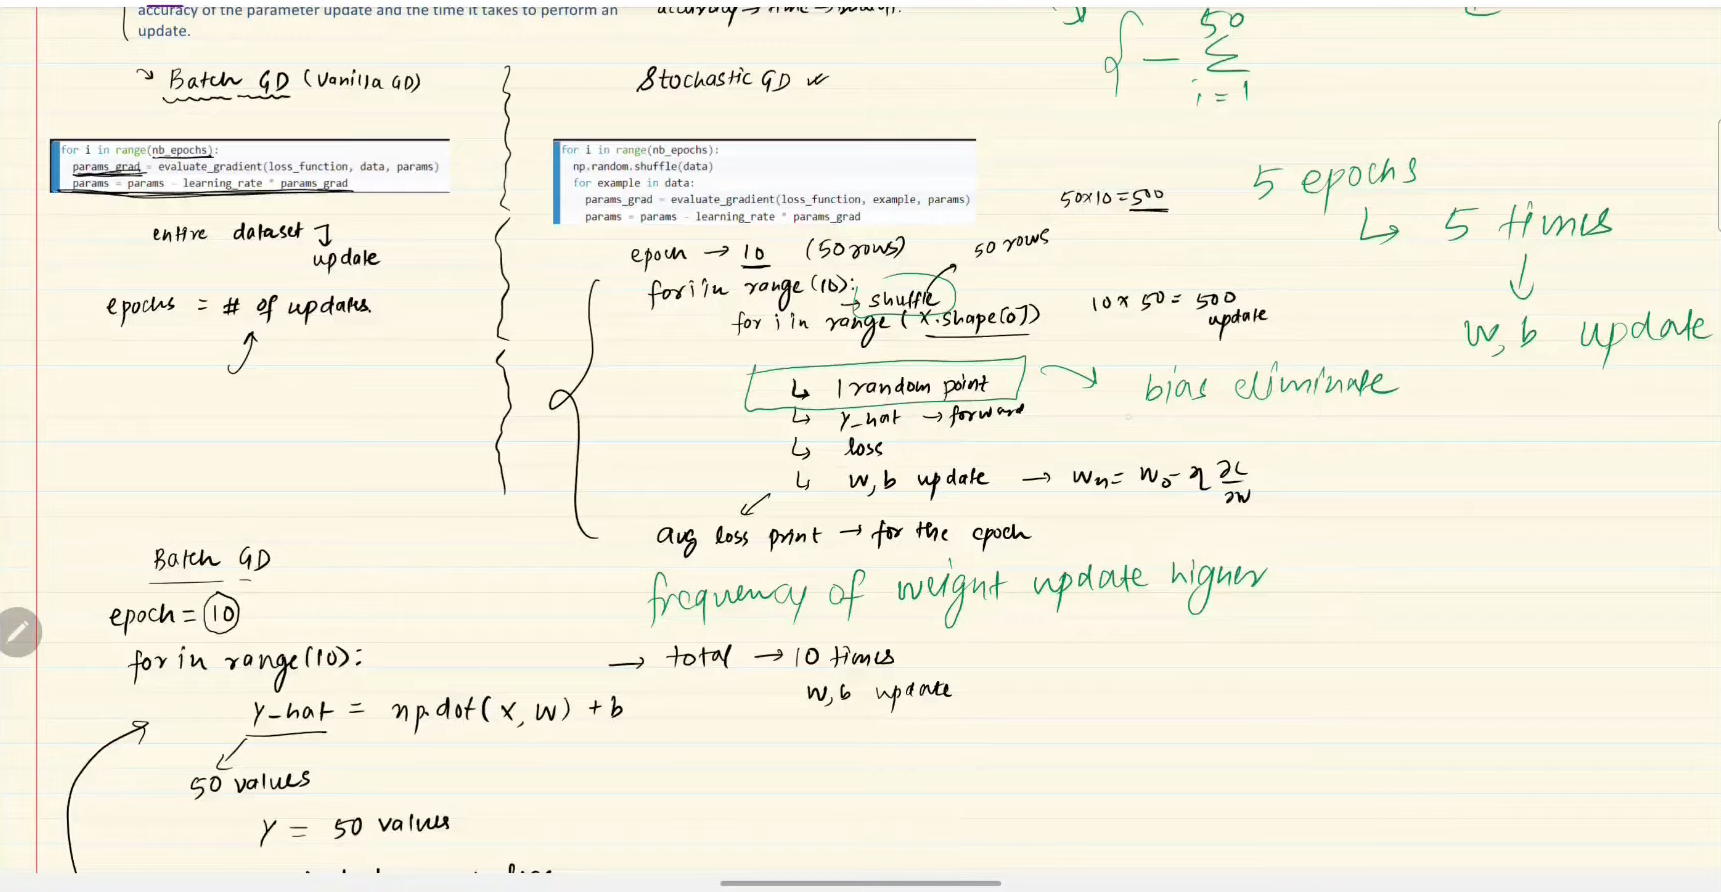

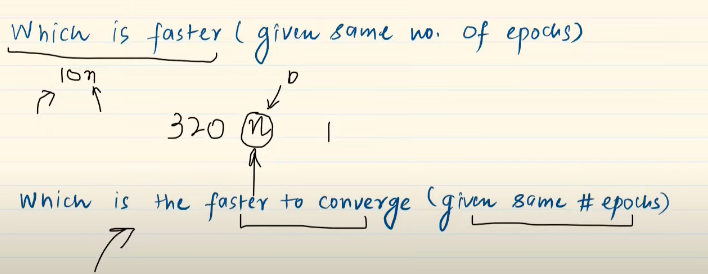

##Answers:
###1. Batch Gradient Descent
###2. SGD


### Q1: Which Gradient Descent method is faster?

- **Stochastic Gradient Descent (SGD)** is the fastest per parameter update because it processes one training example at a time.
- **Mini-Batch Gradient Descent** is fast overall by updating after processing small batches, utilizing parallelism and reducing overhead.
- **Batch Gradient Descent** is the slowest per update since it processes the entire dataset before each update.

### Q2: Which one converges faster?

- **Mini-Batch Gradient Descent** typically converges faster overall because it balances frequent updates with stable gradient estimates, reducing update noise.
- **SGD** converges quickly in terms of update frequency but its path is noisy, so it might take longer to reach an accurate minimum.
- **Batch Gradient Descent** converges steadily but slower in wall-clock time due to heavy computations per update.

### Q3: Why does loss reduction appear smooth in Batch Gradient Descent but spiky in SGD?

- **Batch Gradient Descent** uses the full dataset to compute gradients, averaging out noise and leading to smooth, stable loss reduction.
- **SGD** updates weights per sample, resulting in noisy gradient estimates that cause sharp fluctuations in the loss curve.
- **Mini-Batch Gradient Descent** smooths out these spikes because each update averages over a few samples, reducing noise compared to SGD.

### Q4: Why is Mini-Batch Gradient Descent widely preferred in practice?

- It offers a **balanced trade-off**: faster convergence than batch, less noisy updates than SGD.
- It enables **efficient computation** with hardware like GPUs, through parallel processing of mini-batches.
- It reduces variance in updates for more stable training and better generalization performance.

### Summary Table

| Gradient Descent Type    | Speed per Update | Convergence Speed | Loss Curve Characteristic | Pros                                         | Cons                              |
|-------------------------|------------------|-------------------|---------------------------|----------------------------------------------|----------------------------------|
| Batch                   | Slowest          | Slow              | Smooth                    | Precise gradient, stable updates             | Expensive, slow for big data     |
| Stochastic (SGD)        | Fastest          | Moderate          | Spiky                     | Fast updates, escapes local minima           | Noisy updates, unstable loss     |
| Mini-Batch              | Moderate         | Fastest           | Smoother than SGD         | Efficient, balanced, good convergence        | Needs batch size tuning          |



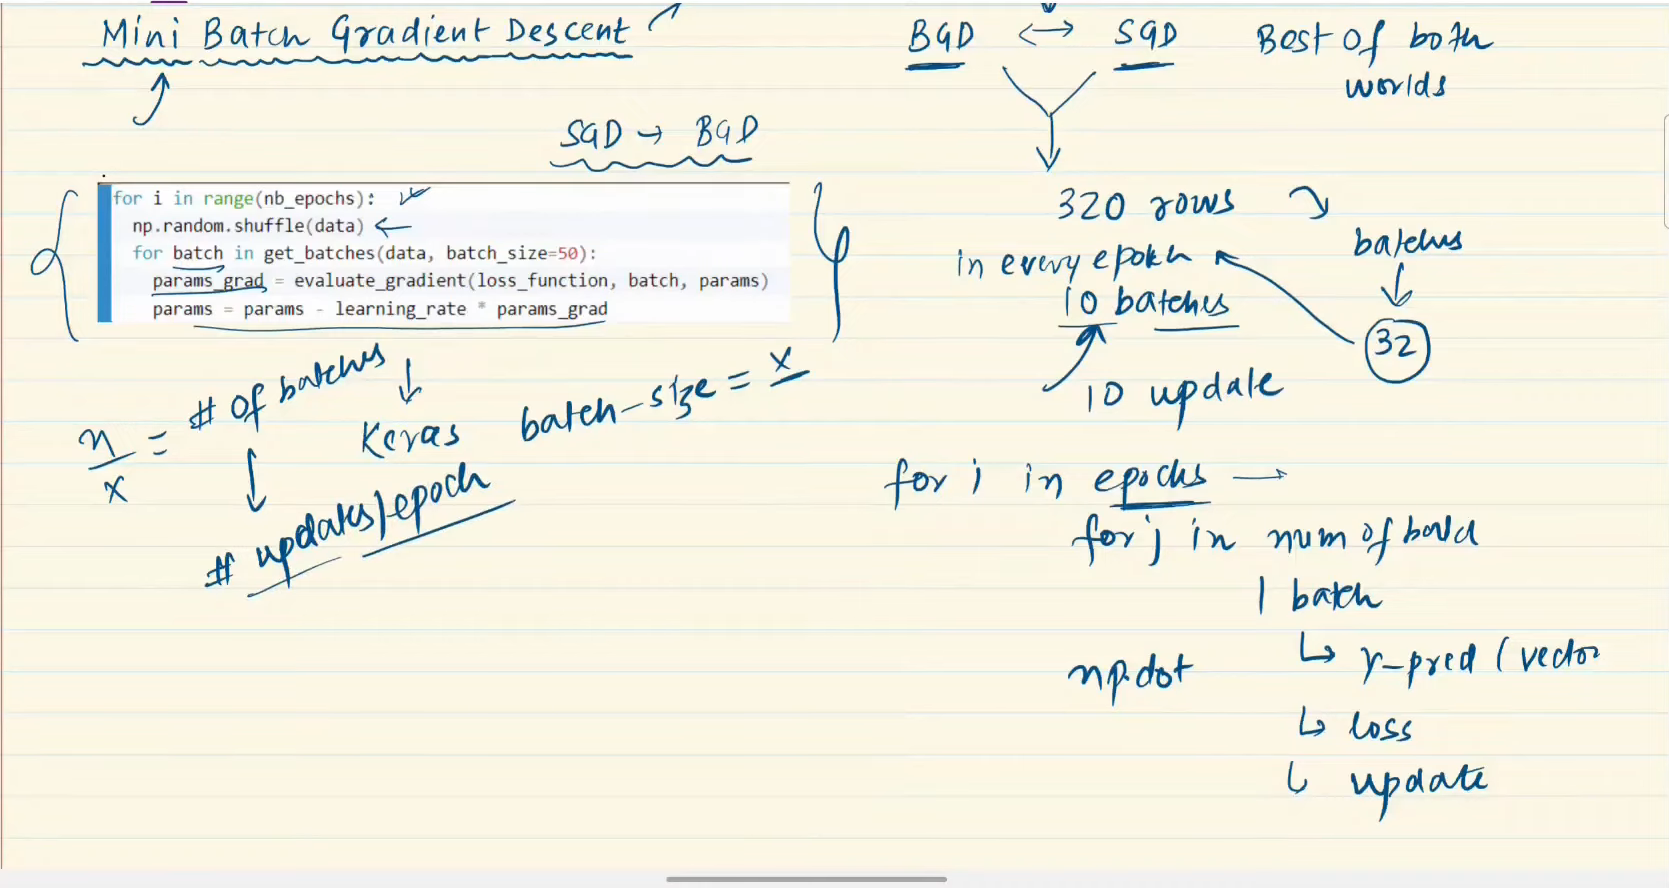

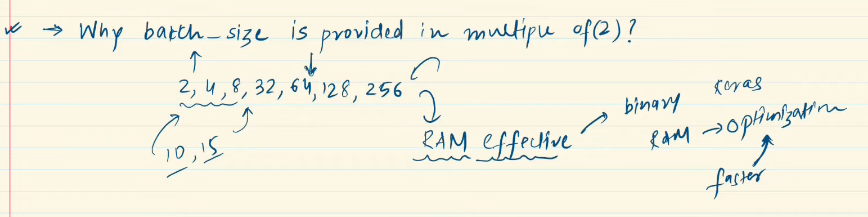

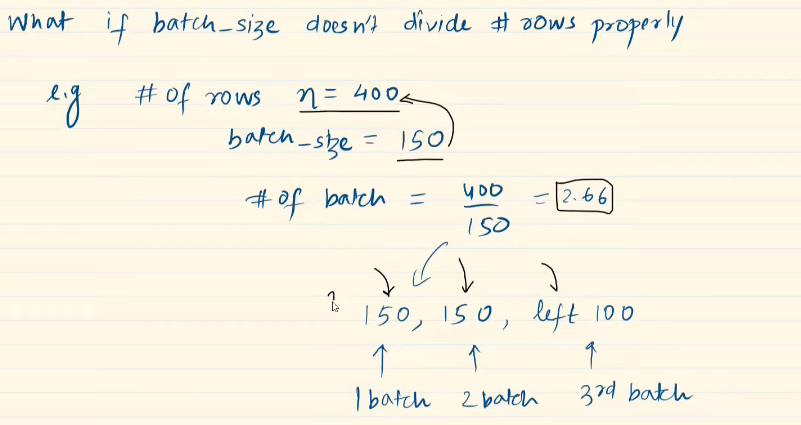





### Concept:

Instead of computing the gradient for each training sample one by one (using loops), the data points are stacked into matrices, and the operations (like dot products, sums, etc.) are done using matrix operations all at once.

This reduces computational overhead and takes advantage of fast low-level implementations for matrix math.

### How vectorization looks mathematically for batch gradient descent:

Given:

- Input data matrix $$ X $$ of shape (number of samples $$ m $$, number of features $$ n $$)  
- Parameter vector $$ \theta $$ of shape (number of features $$ n $$, 1)  
- Target vector $$ y $$ of shape (number of samples $$ m $$, 1)

Predictions:
$$ \hat{y} = X \theta $$

Error vector:
$$ e = \hat{y} - y $$

Gradient (vectorized):
$$ \nabla_\theta J(\theta) = \frac{1}{m} X^T e $$

Parameter update:
$$ \theta := \theta - \alpha \nabla_\theta J(\theta) $$

### Code example (vectorized batch gradient descent for linear regression):

```python
import numpy as np

# X: m samples x n features (with bias column included)
# y: m x 1 target vector
# theta: n x 1 parameter vector
# alpha: learning rate
# iterations: number of iterations

def batch_gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    for _ in range(iterations):
        predictions = X.dot(theta)            # Vectorized prediction (m x 1)
        errors = predictions - y              # Vectorized error (m x 1)
        gradient = (1/m) * X.T.dot(errors)   # Vectorized gradient computation (n x 1)
        theta = theta - alpha * gradient     # Update parameters vectorized
    return theta
```

### Why vectorization is beneficial:

- **Speed:** Matrix operations are performed in optimized C/Fortran backend libraries, outperforming explicit loops in Python.
- **Simplicity:** Code is cleaner and easier to understand.
- **Leverages hardware acceleration:** GPU or SIMD instructions accelerate vectorized operations much better than nested loops.

In summary, vectorization in batch gradient descent means using matrix operations to compute predictions, errors, gradients, and updates for the entire dataset simultaneously rather than looping through individual samples sequentially. This approach provides faster execution and cleaner code.



In [1]:
#Batch Gradient Descent

import numpy as np

X =  np.random.rand(100,2)
y = np.random.rand(100,1)

theta = np.zeros((2,1))
learning_rate = 0.01
epochs = 100

def sigmoid(z):
  return 1/(1+np.exp(-z))

  for epoch in range(epochs):
    z= X.dot(theta)
    predictions = sigmoid(z)
    gradient = X.T.dot(predictions -y)/len(y)
    theta   = theta -learning_rate *gradient

In [3]:
#Stochastic
import numpy as np

X = np.random.rand(100, 2)
y = np.random.rand(100, 1)
theta = np.zeros((2, 1))
learning_rate = 0.01
epochs = 100

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

for epoch in range(epochs):
    for i in range(len(y)):
        xi = X[i, :].reshape(1, -1)
        yi = y[i]
        z = xi.dot(theta)
        pred = sigmoid(z)
        gradient = xi.T.dot(pred - yi)
        theta -= learning_rate * gradient


In [4]:
#Mini-Batch Gradient Descent
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

X_train = np.random.rand(1000, 20)
y_train = np.random.randint(0, 2, size=(1000, 1))

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(20,)),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=10, batch_size=32)  # batch_size=32 means mini-batch[2]


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5025 - loss: 0.6990
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5129 - loss: 0.6947
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5256 - loss: 0.6929
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5297 - loss: 0.6896
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5571 - loss: 0.6860
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5867 - loss: 0.6829
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5634 - loss: 0.6847
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5623 - loss: 0.6838
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5740 - loss: 0.6788
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5581 - loss: 0.6848


In [5]:
X_train

array([[0.65247705, 0.89493497, 0.60489232, ..., 0.00918168, 0.44763633,
        0.81949528],
       [0.95888427, 0.22367099, 0.80486615, ..., 0.41763894, 0.35541472,
        0.95970408],
       [0.66851197, 0.56634541, 0.55071986, ..., 0.49826388, 0.42084538,
        0.30881908],
       ...,
       [0.67709948, 0.28979835, 0.39835558, ..., 0.14318287, 0.07392848,
        0.04398337],
       [0.58887954, 0.32709597, 0.72939849, ..., 0.46993946, 0.77191167,
        0.26670796],
       [0.86773807, 0.4212593 , 0.88449908, ..., 0.24098633, 0.24190483,
        0.62964972]])

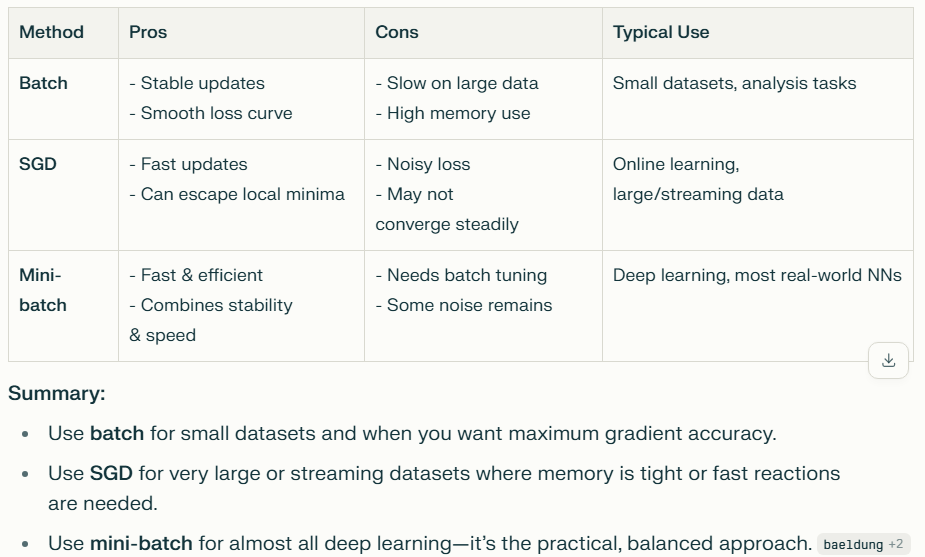